# Système d’aide au tri radiologique (NIH Chest x-rays dataset)

In [2]:
import os
import numpy as np

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from pathlib import Path

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, classification_report

## Chargement du dataset

In [3]:
DATASET_DIR = Path("/kaggle/input/datasets/organizations/nih-chest-xrays/data")

df = pd.read_csv(DATASET_DIR / "Data_Entry_2017.csv")

print("Shape :", df.shape)
print(df.head())
print(df.dtypes)
print("\nValeurs manquantes :\n", df.isnull().sum())

Shape : (112120, 12)
        Image Index          Finding Labels  Follow-up #  Patient ID  \
0  00000001_000.png            Cardiomegaly            0           1   
1  00000001_001.png  Cardiomegaly|Emphysema            1           1   
2  00000001_002.png   Cardiomegaly|Effusion            2           1   
3  00000002_000.png              No Finding            0           2   
4  00000003_000.png                  Hernia            0           3   

   Patient Age Patient Gender View Position  OriginalImage[Width  Height]  \
0           58              M            PA                 2682     2749   
1           58              M            PA                 2894     2729   
2           58              M            PA                 2500     2048   
3           81              M            PA                 2500     2048   
4           81              F            PA                 2582     2991   

   OriginalImagePixelSpacing[x     y]  Unnamed: 11  
0                        0.143

## Construction du dict des images

In [4]:
img_paths = {}
for p in DATASET_DIR.glob("images_*/images/*.png"):
    img_paths[p.name] = str(p)

print(f"{len(img_paths)} images trouvées")

112120 images trouvées


## EDA

### EDA : distribution des pathologies

/tmp/ipykernel_489/3835272238.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=label_df, x="Label", y="Count", palette="viridis")


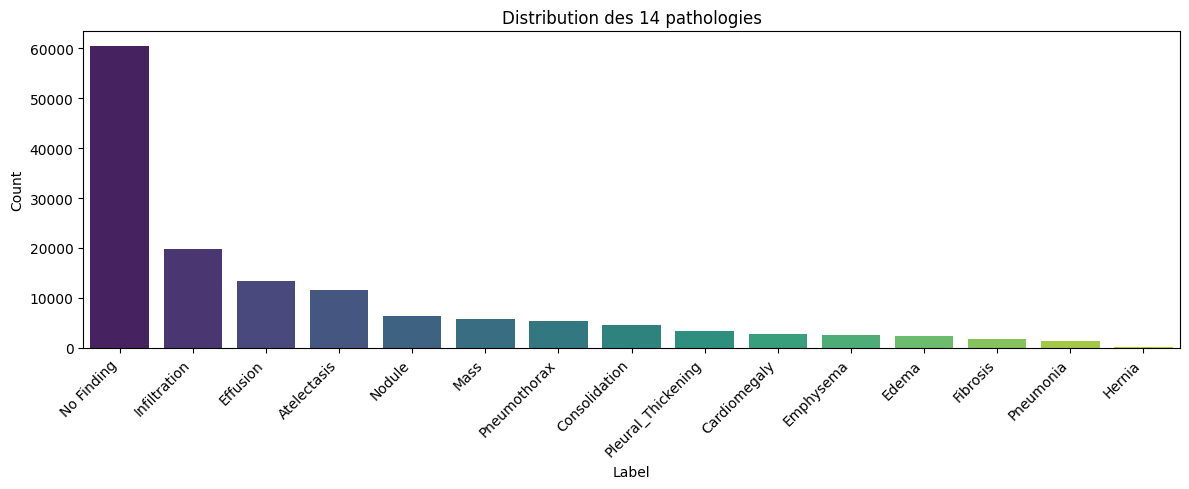

In [5]:
all_labels = []
for labels in df["Finding Labels"]:
    all_labels.extend(labels.split("|"))

label_counts = Counter(all_labels)
label_df = pd.DataFrame(label_counts.items(), columns=["Label", "Count"]).sort_values("Count", ascending=False)

plt.figure(figsize=(12, 5))
sns.barplot(data=label_df, x="Label", y="Count", palette="viridis")
plt.xticks(rotation=45, ha="right")
plt.title("Distribution des 14 pathologies")
plt.tight_layout()
plt.show()

### EDA : distribution âge / genre

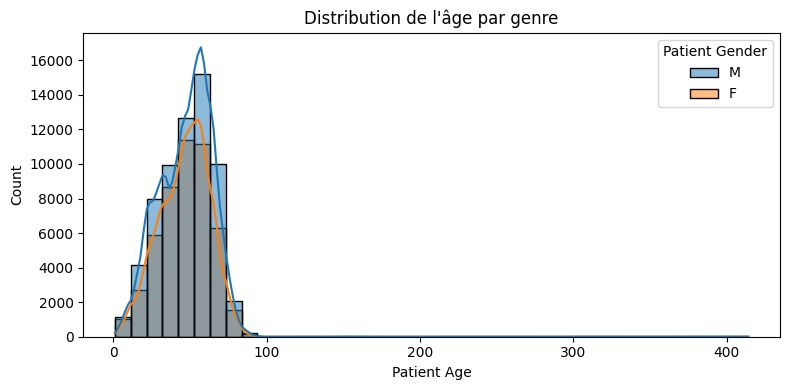

In [6]:
plt.figure(figsize=(8, 4))
sns.histplot(data=df, x="Patient Age", hue="Patient Gender", bins=40, kde=True)
plt.title("Distribution de l'âge par genre")
plt.tight_layout()
plt.show()

### EDA : heatmap co-occurrences

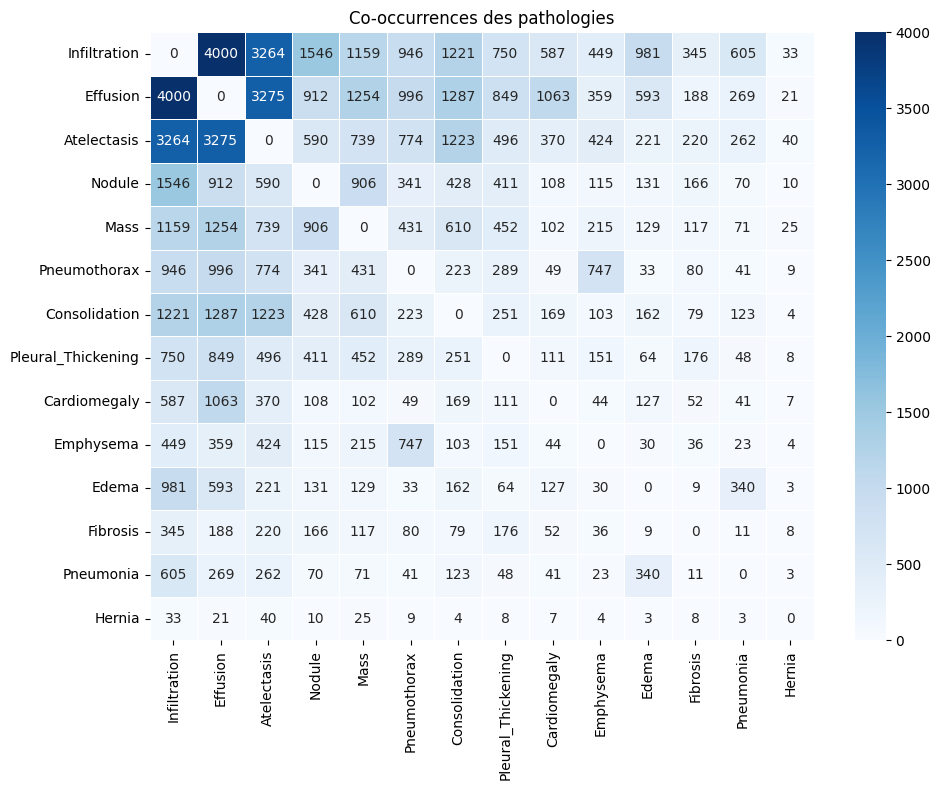

In [7]:
DISEASES = [l for l in label_df["Label"] if l != "No Finding"][:14]

for d in DISEASES:
    df[d] = df["Finding Labels"].str.contains(d).astype(int)

cooc = df[DISEASES].T.dot(df[DISEASES])
np.fill_diagonal(cooc.values, 0)

plt.figure(figsize=(10, 8))
sns.heatmap(cooc, annot=True, fmt="d", cmap="Blues", linewidths=0.5)
plt.title("Co-occurrences des pathologies")
plt.tight_layout()
plt.show()

### EDA : nombre de labels par image & vue radiologique

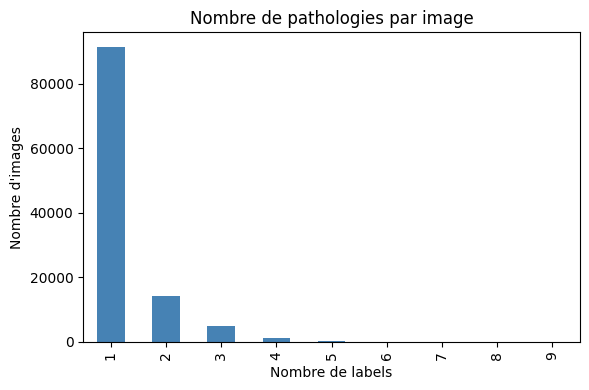

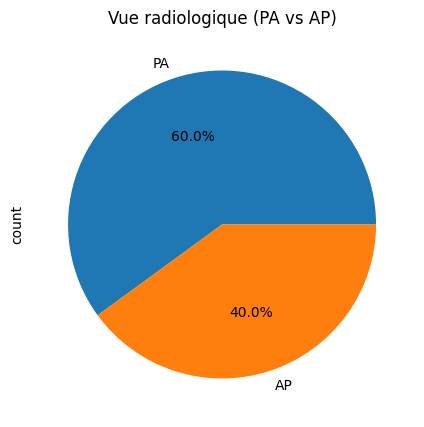

In [8]:
df["n_labels"] = df["Finding Labels"].apply(lambda x: len(x.split("|")))

plt.figure(figsize=(6, 4))
df["n_labels"].value_counts().sort_index().plot(kind="bar", color="steelblue")
plt.title("Nombre de pathologies par image")
plt.xlabel("Nombre de labels")
plt.ylabel("Nombre d'images")
plt.tight_layout()
plt.show()

df["View Position"].value_counts().plot.pie(autopct="%1.1f%%", figsize=(5, 5))
plt.title("Vue radiologique (PA vs AP)")
plt.show()

## Preprocessing & split

In [9]:
available = set(img_paths.keys())
df_clean = df[df["Image Index"].isin(available)].copy()
print(f"{len(df_clean)} images après filtrage")

def get_label_vector(label_str):
    present = label_str.split("|")
    return [1.0 if d in present else 0.0 for d in DISEASES]

df_clean["label_vec"] = df_clean["Finding Labels"].apply(get_label_vector)

train_df, test_df = train_test_split(df_clean, test_size=0.30, random_state=42)
val_df,   test_df = train_test_split(test_df,  test_size=0.50, random_state=42)

print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")

112120 images après filtrage
Train: 78484 | Val: 16818 | Test: 16818


## Dataset & DataLoaders

In [10]:
class ChestXrayDataset(Dataset):
    def __init__(self, dataframe, img_paths, transform=None):
        self.df        = dataframe.reset_index(drop=True)
        self.img_paths = img_paths
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        fname = self.df.loc[idx, "Image Index"]
        img   = Image.open(self.img_paths[fname]).convert("RGB")
        if self.transform:
            img = self.transform(img)
        label = torch.tensor(self.df.loc[idx, "label_vec"], dtype=torch.float32)
        return img, label


train_tfm = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])

val_tfm = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])

train_loader = DataLoader(ChestXrayDataset(train_df, img_paths, train_tfm), batch_size=64, shuffle=True,  num_workers=2)
val_loader   = DataLoader(ChestXrayDataset(val_df,   img_paths, val_tfm),   batch_size=64, shuffle=False, num_workers=2)
test_loader  = DataLoader(ChestXrayDataset(test_df,  img_paths, val_tfm),   batch_size=64, shuffle=False, num_workers=2)

In [11]:
torch.backends.cudnn.benchmark = True
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("GPU disponible :", torch.cuda.is_available())
print("Device :", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")
print("Images trouvées :", len(img_paths))
print("Lignes dans df_clean :", len(df_clean))

sample_img, sample_label = ChestXrayDataset(train_df, img_paths, val_tfm)[0]
print("Shape image :", sample_img.shape)    # torch.Size([3, 224, 224])
print("Shape label :", sample_label.shape)  # torch.Size([14])

GPU disponible : True
Device : Tesla T4
Images trouvées : 112120
Lignes dans df_clean : 112120
Shape image : torch.Size([3, 224, 224])
Shape label : torch.Size([14])


## Modele ResNet-50

In [12]:
model = models.resnet50(weights="IMAGENET1K_V2")

for param in model.parameters():
    param.requires_grad = False

model.fc = nn.Sequential(
    nn.Linear(model.fc.in_features, 512),
    nn.ReLU(),
    nn.Dropout(0.4),
    nn.Linear(512, len(DISEASES)),
)
model = model.to(DEVICE)

criterion = nn.BCEWithLogitsLoss()
optimizer = optim.AdamW(model.fc.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10)

print(model.fc)

Sequential(
  (0): Linear(in_features=2048, out_features=512, bias=True)
  (1): ReLU()
  (2): Dropout(p=0.4, inplace=False)
  (3): Linear(in_features=512, out_features=14, bias=True)
)


In [13]:
import torch
print(torch.__version__)            # 2.2.0+cu118
print(torch.cuda.is_available())    # True

x = torch.randn(4, 3, 224, 224).cuda()
print("GPU OK :", x.shape)

2.10.0+cu128
True
GPU OK : torch.Size([4, 3, 224, 224])


In [14]:
import numpy as np
import torch
print("Numpy :", np.__version__)       # doit afficher 1.26.4
print("Torch :", torch.__version__)    # 2.1.0+cu128
print("CUDA  :", torch.cuda.is_available())  # True

# Test que numpy + torch cohabitent bien
x = torch.randn(4, 3, 224, 224).cuda()
arr = x.cpu().numpy()
print("Conversion GPU→numpy OK, shape :", arr.shape)

Numpy : 2.0.2
Torch : 2.10.0+cu128
CUDA  : True
Conversion GPU→numpy OK, shape : (4, 3, 224, 224)


## Entrainement

In [15]:
from tqdm.notebook import tqdm

def train_one_epoch(model, loader):
    model.train()
    total_loss = 0
    for imgs, labels in tqdm(loader, desc="Train", leave=False):
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        loss = criterion(model(imgs), labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)

def evaluate(model, loader):
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            total_loss += criterion(model(imgs), labels).item()
    return total_loss / len(loader)


EPOCHS = 4
history = {"train_loss": [], "val_loss": []}

for epoch in range(1, EPOCHS + 1):
    tr_loss  = train_one_epoch(model, train_loader)
    val_loss = evaluate(model, val_loader)
    scheduler.step()
    history["train_loss"].append(tr_loss)
    history["val_loss"].append(val_loss)
    print(f"Epoch {epoch:02d} | Train Loss: {tr_loss:.4f} | Val Loss: {val_loss:.4f}")

torch.save(model.state_dict(), "chestxray_resnet50.pth")

Train:   0%|          | 0/1227 [00:00<?, ?it/s]

Epoch 01 | Train Loss: 0.1794 | Val Loss: 0.1695


Train:   0%|          | 0/1227 [00:00<?, ?it/s]

Epoch 02 | Train Loss: 0.1737 | Val Loss: 0.1684


Train:   0%|          | 0/1227 [00:00<?, ?it/s]

Epoch 03 | Train Loss: 0.1722 | Val Loss: 0.1670


Train:   0%|          | 0/1227 [00:00<?, ?it/s]

Epoch 04 | Train Loss: 0.1714 | Val Loss: 0.1663


## Courbe de loss

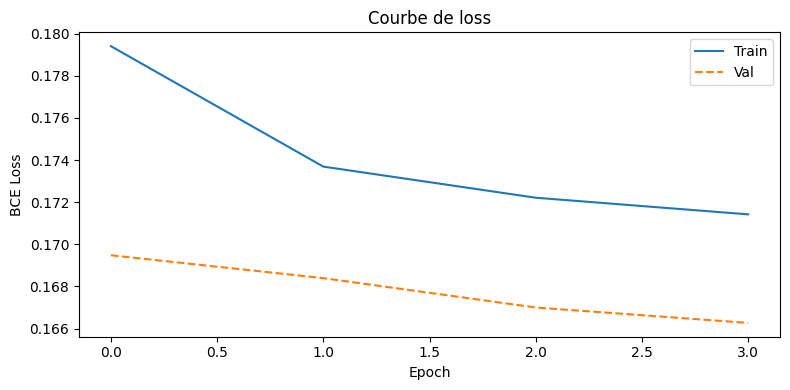

In [16]:
plt.figure(figsize=(8, 4))
plt.plot(history["train_loss"], label="Train")
plt.plot(history["val_loss"],   label="Val", linestyle="--")
plt.title("Courbe de loss")
plt.xlabel("Epoch")
plt.ylabel("BCE Loss")
plt.legend()
plt.tight_layout()
plt.show()

## Évaluation AUC-ROC

           Disease      AUC
             Edema 0.830931
      Pneumothorax 0.813160
          Effusion 0.790879
         Emphysema 0.781355
     Consolidation 0.747447
      Cardiomegaly 0.746015
            Hernia 0.740168
       Atelectasis 0.721442
          Fibrosis 0.712486
Pleural_Thickening 0.703738
              Mass 0.692434
      Infiltration 0.665335
            Nodule 0.645877
         Pneumonia 0.637598


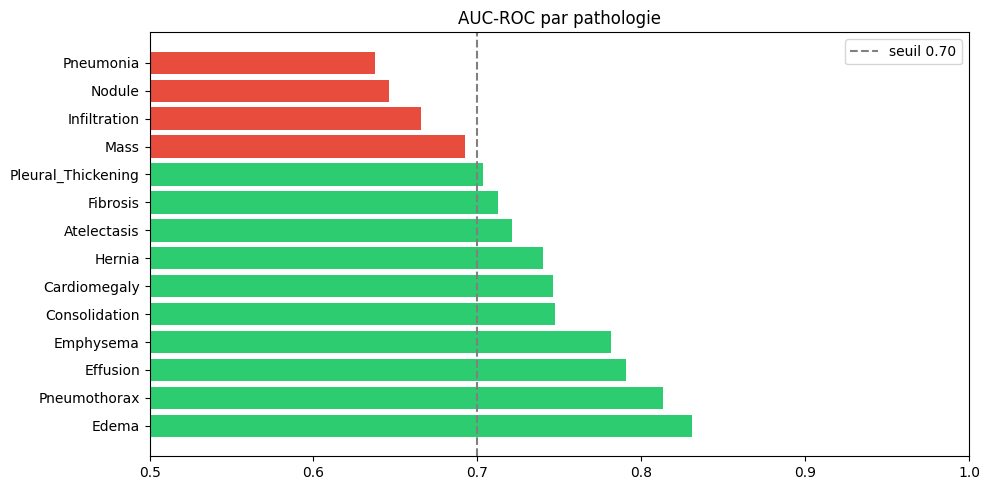

In [17]:
model.eval()
all_probs, all_labels_list = [], []

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(DEVICE)
        probs = torch.sigmoid(model(imgs)).cpu().numpy()
        all_probs.append(probs)
        all_labels_list.append(labels.numpy())

all_probs  = np.vstack(all_probs)
all_labels_arr = np.vstack(all_labels_list)

aucs = {}
for i, disease in enumerate(DISEASES):
    try:
        aucs[disease] = roc_auc_score(all_labels_arr[:, i], all_probs[:, i])
    except ValueError:
        aucs[disease] = float("nan")

auc_df = pd.DataFrame(aucs.items(), columns=["Disease", "AUC"]).sort_values("AUC", ascending=False)
print(auc_df.to_string(index=False))

colors = ["#2ecc71" if v >= 0.7 else "#e74c3c" for v in auc_df["AUC"]]
plt.figure(figsize=(10, 5))
plt.barh(auc_df["Disease"], auc_df["AUC"], color=colors)
plt.axvline(0.7, color="gray", linestyle="--", label="seuil 0.70")
plt.xlim(0.5, 1.0)
plt.title("AUC-ROC par pathologie")
plt.legend()
plt.tight_layout()
plt.show()

## Rapport de classification

In [19]:
# Cherche le meilleur seuil par pathologie
from sklearn.metrics import f1_score

best_thresholds = []
for i, disease in enumerate(DISEASES):
    best_t, best_f1 = 0.5, 0
    for t in np.arange(0.1, 0.9, 0.05):
        f1 = f1_score(all_labels_arr[:, i], (all_probs[:, i] >= t).astype(int), zero_division=0)
        if f1 > best_f1:
            best_f1 = f1
            best_t = t
    best_thresholds.append(best_t)
    print(f"{disease:25s} → seuil optimal : {best_t:.2f}  (F1: {best_f1:.3f})")

# Applique les seuils optimaux
preds_binary = np.stack([
    (all_probs[:, i] >= best_thresholds[i]).astype(int)
    for i in range(len(DISEASES))
], axis=1)

print("\n", classification_report(all_labels_arr, preds_binary, target_names=DISEASES, zero_division=0))

Infiltration              → seuil optimal : 0.20  (F1: 0.364)
Effusion                  → seuil optimal : 0.20  (F1: 0.394)
Atelectasis               → seuil optimal : 0.15  (F1: 0.296)
Nodule                    → seuil optimal : 0.10  (F1: 0.163)
Mass                      → seuil optimal : 0.10  (F1: 0.188)
Pneumothorax              → seuil optimal : 0.10  (F1: 0.268)
Consolidation             → seuil optimal : 0.10  (F1: 0.166)
Pleural_Thickening        → seuil optimal : 0.10  (F1: 0.079)
Cardiomegaly              → seuil optimal : 0.10  (F1: 0.123)
Emphysema                 → seuil optimal : 0.10  (F1: 0.168)
Edema                     → seuil optimal : 0.10  (F1: 0.150)
Fibrosis                  → seuil optimal : 0.10  (F1: 0.007)
Pneumonia                 → seuil optimal : 0.50  (F1: 0.000)
Hernia                    → seuil optimal : 0.50  (F1: 0.000)

                     precision    recall  f1-score   support

      Infiltration       0.27      0.55      0.36      2903
         